# Grammaires de visualisation en Python : Plotnine vs Altair

**Module Data Visualisation (M2 EIA)**

*Enseignant : Jean Delpech*

Version : *Octobre 2026*

---

Ce notebook compare deux bibliothèques Python qui implémentent, chacune à sa manière, une **grammaire de visualisation** : [Plotnine](https://github.com/has2k1/plotnine) (portage direct de ggplot2/R) et [Altair](https://altair-viz.github.io/) (API Python pour Vega-Lite).

L'objectif n'est pas d'apprendre la syntaxe par cœur, mais de comprendre **pourquoi** penser "en grammaire" (données → encodage → marque géométrique) change la façon de concevoir un graphique, par rapport à une approche "catalogue de types de graphiques" (bar chart, pie chart, etc.).

## Sommaire
1. Introduction : la grammaire de visualisation
2. Plotnine : la grammaire de ggplot2 en Python
3. Altair : la grammaire de Vega-Lite en Python
4. Conclusion


In [1]:
# Imports communs et chargement des jeux de données
import seaborn as sns
import pandas as pd

pd.set_option("display.max_columns", 10)

# On charge des jeux de données classiques (via seaborn)
tips = sns.load_dataset("tips")
iris = sns.load_dataset("iris")
penguins = sns.load_dataset("penguins").dropna()  # on retire les lignes incomplètes

print("tips :", tips.shape)
print("iris :", iris.shape)
print("penguins :", penguins.shape)

tips.head()


tips : (244, 7)
iris : (150, 5)
penguins : (333, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


# 1. Introduction : la grammaire de visualisation

## 1.1 Principes théoriques

Une **grammaire de visualisation** part d'un constat : plutôt que de raisonner en « types de graphiques » prédéfinis (histogramme, camembert, nuage de points...),
on peut décomposer *tout* graphique statistique en une poignée de composants indépendants et combinables. L'idée vient de Leland Wilkinson, *The Grammar of Graphics* (Springer, 1999/2005), puis a été reformulée et popularisée par Hadley Wickham dans *A Layered Grammar of Graphics* (2010), qui est devenue la base de `ggplot2` (en R).

Les composants de cette grammaire « en couches » (*layered grammar*) sont, schématiquement :

| Composant | Rôle | Exemple |
|---|---|---|
| **Data** | Le jeu de données (un DataFrame) | `tips` |
| **Mapping (aesthetic / encoding)** | Quelle colonne va sur quel « canal » | `x = total_bill`, `color = time` |
| **Geom / Mark** | La forme géométrique qui représente une observation | point, barre, ligne |
| **Stat (transformation statistique)** | Un résumé calculé avant affichage | moyenne, régression, densité |
| **Scale** | Comment une valeur de donnée devient une valeur visuelle | échelle de couleur, échelle log |
| **Coord (système de coordonnées)** | Cartésien, polaire, projection carto | `coord_flip()` |
| **Facet** | Répétition du graphique par sous-groupe (petits multiples) | une facette par espèce |
| **Theme** | L'habillage visuel non lié aux données | polices, grilles, couleurs de fond |

La logique change un peu de ce à quoi on est habitué quand on code avec les modules « classiques » de dataviz. 

Quand on conçoit une dataviz on ne part plus de la question *« quel type de graphique dois-je choisir ? »*, mais plutôt *« quelles variables je veux
encoder, et sur quels canaux (position, couleur, taille, forme) ? »*. Un nuage de points coloré et un histogramme empilé ne sont alors plus deux objets
différents, mais deux combinaisons différentes des mêmes briques. C'est ce qui rend la grammaire *composable* et *prévisible*, contrairement à une API du type
« une fonction par type de graphique » (comme le `matplotlib` ou le `seaborn` que vous connaissez déjà).

## 1.2 Galerie — quelques réalisations connues de cette approche

- **ggplot2 (R)** : c’est l'implémentation de référence, omniprésente en recherche et en datajournalisme. La **BBC** a par exemple créé [`bbplot`](https://github.com/bbc/bbplot), un package qui habille des graphiques `ggplot2` au style visuel de la BBC News. Elle est notamment utilisée en production par l'équipe *Visual and Data Journalism* depuis 2018.
- **Vega / Vega-Lite** : une grammaire équivalente mais pensée pour le web et l'**interaction** (on verra cela en détail le jour 2 et quelques exemples à la fin de ce notebook). Elle alimente notamment [Observable Plot](https://observablehq.com/plot/) (créé par Mike Bostock, l'auteur de `D3.js`).
- **Galerie d'exemples Vega-Lite** : [vega.github.io/vega-lite/examples](https://vega.github.io/vega-lite/examples/) qui propose un bon aperçu de la diversité de graphiques exprimables avec une grammaire compacte (y compris des graphiques interactifs en quelques lignes de JSON).

Cette approche offre la possibilité de raisonner sur un graphique *avant* de l'écrire (quel encodage pour quelle tâche analytique ?), une plus grande cohérence entre graphiques d'un même projet, et une portabilité des spécifications (un même « vocabulaire » conceptuel existe en R, en Python, et nativement sur le web). Au delà de la création ponctuelle de dataviz dans un contexte précis (liée à une étude ou un dataset donné), cela simplifie beaucoup la vie du développeur lorsqu’il doit créer des solutions plus générales et personnalisables ou configurables par l’utilisateur.

## 1.3 Ressources théoriques

- **Livre** : Leland Wilkinson, *The Grammar of Graphics*, Springer, 2e éd. 2005 (l'ouvrage fondateur).
- **Article** : Hadley Wickham, [*A Layered Grammar of Graphics*](https://vita.had.co.nz/papers/layered-grammar.html), *Journal of Computational and Graphical Statistics*, 2010. C’est la reformulation qui a donné naissance à `ggplot2`. Plus accessible que le livre de Wilkinson.
- **Article** : Satyanarayan, Moritz, Wongsuphasawat & Heer, [*Vega-Lite: A Grammar of Interactive Graphics*](https://idl.uw.edu/papers/vega-lite), IEEE
  TVCG, 2017 (Best Paper Award). Ajoute la gestion de l'**interaction**, Altair se fonde sur cette grammaire.
- **Cours / notebooks ouverts** : [UW Data Visualization Curriculum](https://github.com/uwdata/visualization-curriculum) : une série complète de notebooks Jupyter (Altair) développée par l'équipe de recherche à l'origine de Vega-Lite. N’hésitez pas à les utiliser pour approfondir votre maîtrise d’Atair.
- **Documentation** : [vega.github.io/vega-lite/docs](https://vega.github.io/vega-lite/docs/) (aborde Vega-lite seulement, pas Altair.)


# 2. Plotnine : ggplot2 en Python

[Plotnine](https://github.com/has2k1/plotnine) est un **portage quasi littéral** de `ggplot2` en Python : même syntaxe par couches additionnées avec `+`, mêmes
noms de fonctions (`aes()`, `geom_point()`, `facet_wrap()`...). Elle est un peu à la dataviz ce que l’API de `statsmodels` est aux formules en Patsy. ̀Si vous
connaissez `ggplot2` en R, vous connaissez déjà 90% de l'API de `plotnine`. Voici la [documentation officielle de ggplot2](https://ggplot2.tidyverse.org/reference/index.html) qui vous servira de référence complémentaire lorsque la doc de `plotnine` sera insuffisante.

## 2.1 Comment la théorie est implémentée

Chaque ligne de code plotnine correspond directement à un composant de la grammaire vue ci-dessus :

```python
(
    ggplot(data, aes(x=..., y=..., color=...))  # Data + Mapping
    + geom_point()                               # Geom
    + stat_smooth(method="lm")                   # Stat
    + scale_color_brewer(type="qual")             # Scale
    + facet_wrap("~ une_colonne")                 # Facet
    + theme_minimal()                             # Theme
)
```

On **additionne** des couches : chaque `+` ajoute un composant indépendant des autres, ce qui permet de construire un graphique complexe petit bout par petit
bout, et de réutiliser un objet `ggplot` de base en lui ajoutant différentes couches.

In [4]:
# !pip install plotnine # décommentez si vous n’avez pas plotline d’installé

In [5]:
from plotnine import (
    ggplot, aes, geom_point, geom_smooth, geom_bar, geom_boxplot,
    facet_wrap, theme_minimal, labs, stat_summary
)


### Exemple A : Nuage de points avec des droites de régression (`tips`)

On va créer un graphe avec l’encodage suivant : 
- `x` = « addition totale »
- `y` = « pourboire »
- `color` = « moment du repas »
- et les droites de tendance correspondantes


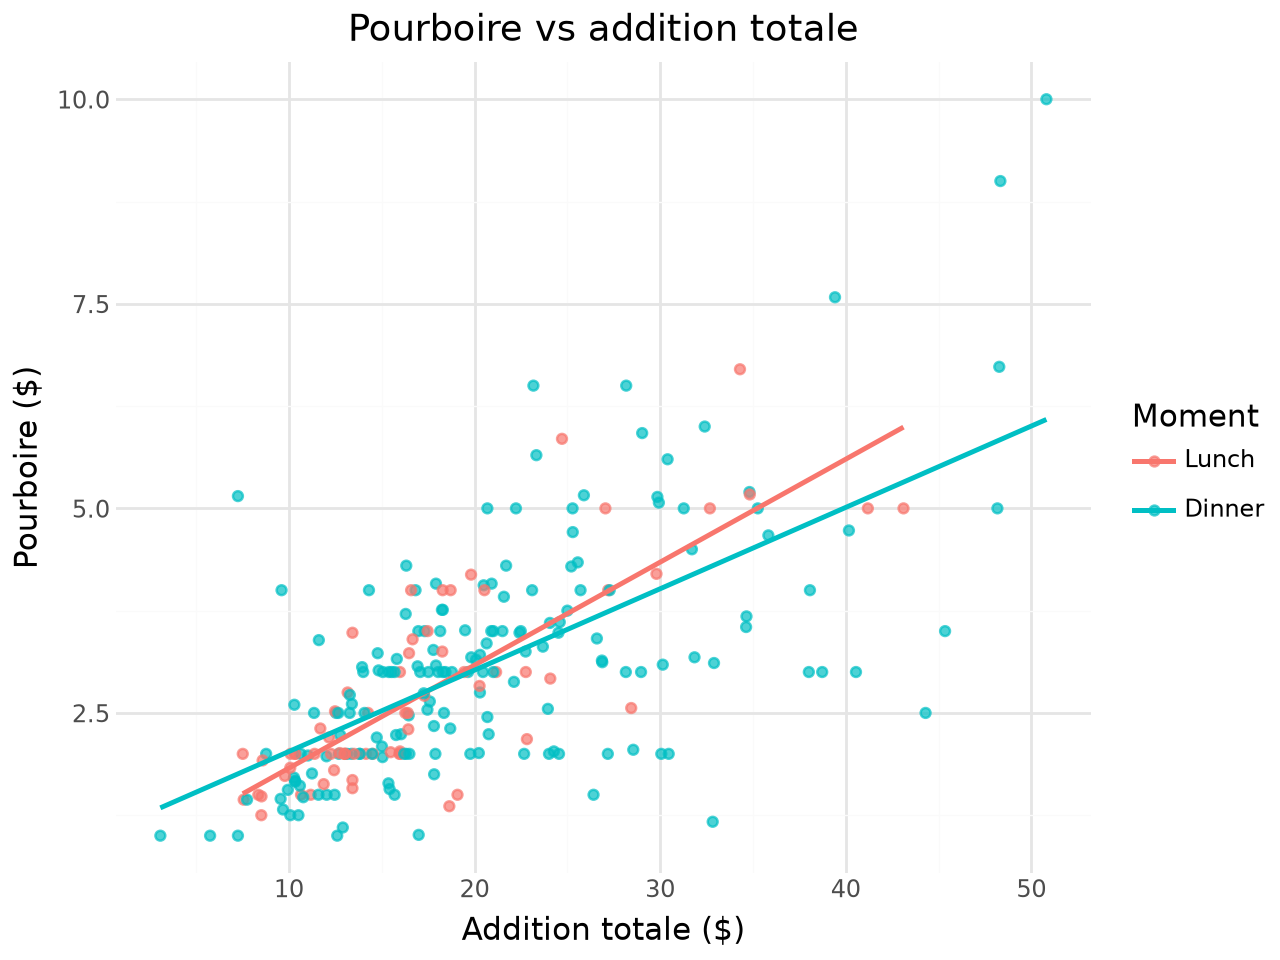

In [6]:
(
    ggplot(tips, aes(x="total_bill", y="tip", color="time"))
    + geom_point(alpha=0.7)
    + geom_smooth(method="lm", se=False)
    + labs(
        title="Pourboire vs addition totale",
        x="Addition totale ($)", y="Pourboire ($)", color="Moment",
    )
    + theme_minimal()
)


### Exemple B : Comparaison de catégories (`iris`)

On va vouloir cette fois créer un graphe généré par l’encodage suivant (un bargraph basique) : 
- une barre par espèce
- hauteur = « longueur moyenne des pétales »

> Notez bien qu’on définit explicitement une composante `stat_summary` : c'est le composant **Stat** de la grammaire, on ne pré-agrège pas les données nous-mêmes, on délègue le calcul de la moyenne à la grammaire.
>
> Il faut s’astreinde à la gymnastique cérébrale de bien décomposer et lister ce qu’on veut afficher et comment, élément par élément


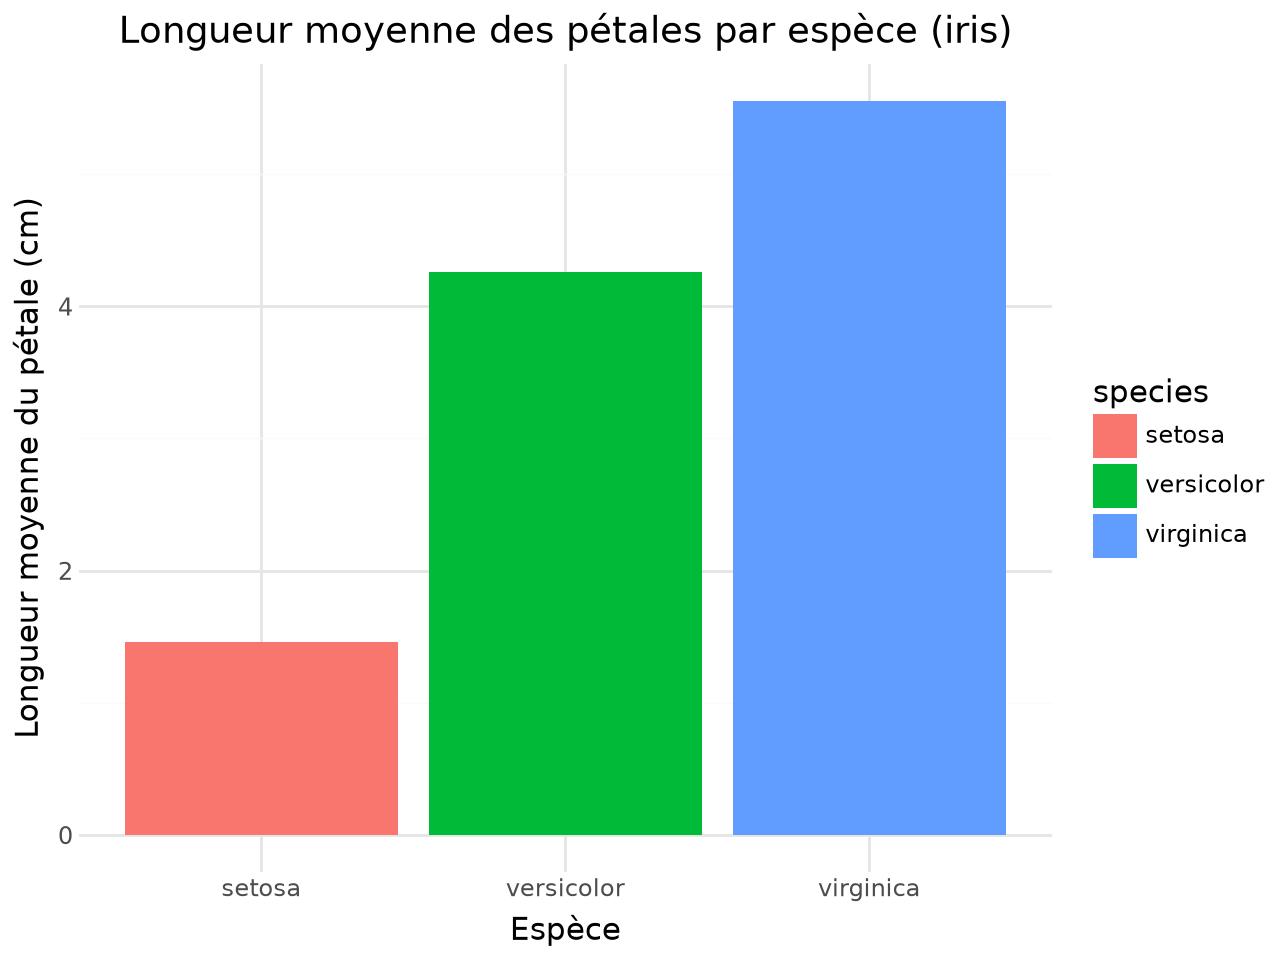

In [7]:
(
    ggplot(iris, aes(x="species", y="petal_length", fill="species"))
    + stat_summary(fun_y=None, fun_data="mean_cl_normal", geom="col")
    + labs(
        title="Longueur moyenne des pétales par espèce (iris)",
        x="Espèce", y="Longueur moyenne du pétale (cm)",
    )
    + theme_minimal()
)


### Exemple C : Distribution par groupe (`tips`)

Cette fois-ci, on veut encoder : 
- une boîte à moustaches par jour (pour comparer la distribution des pourboires)


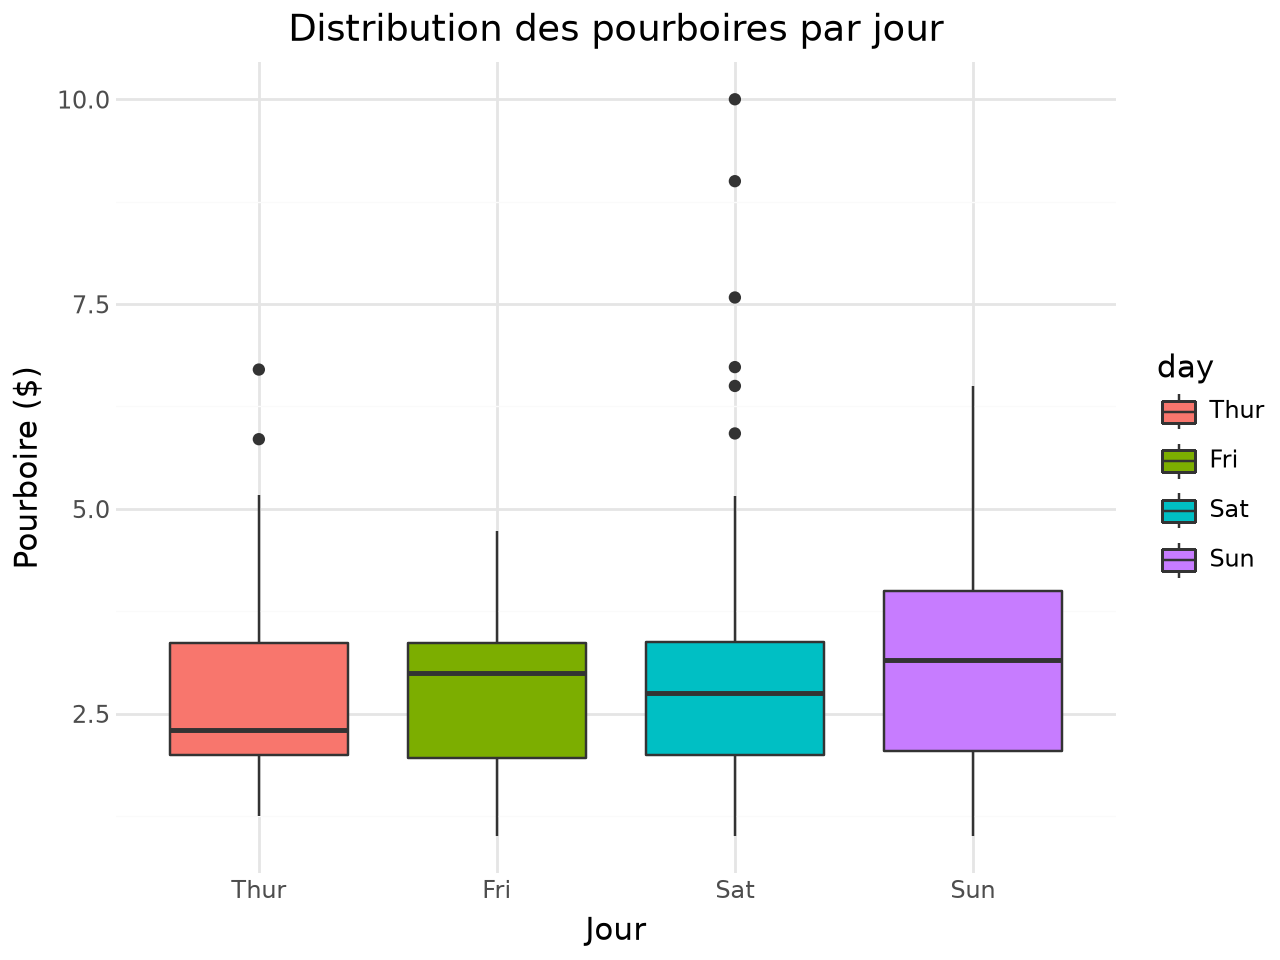

In [8]:
(
    ggplot(tips, aes(x="day", y="tip", fill="day"))
    + geom_boxplot()
    + labs(
        title="Distribution des pourboires par jour",
        x="Jour", y="Pourboire ($)",
    )
    + theme_minimal()
)


### Exemple D : « small-multiples » / facettes (`penguins`)

Cette fois-ci on va faire un graphe plus comlexe : 
- un panneau par espèce
- les axes `x`/`y` correspondront aux dimensions du bec (longueur/profondeur)
- `color` = île

C'est là qu’on voit la puissance de la grammaire : le facettage (`facet_wrap`) est un composant *indépendant* de l'encodage. On peut l'ajouter ou le retirer
sans toucher au reste du graphique (rappellez vous comment on galère pour faire un multigraphe avec `matplotlib` et comment il faut tout reprendre si on modifie le découpage)


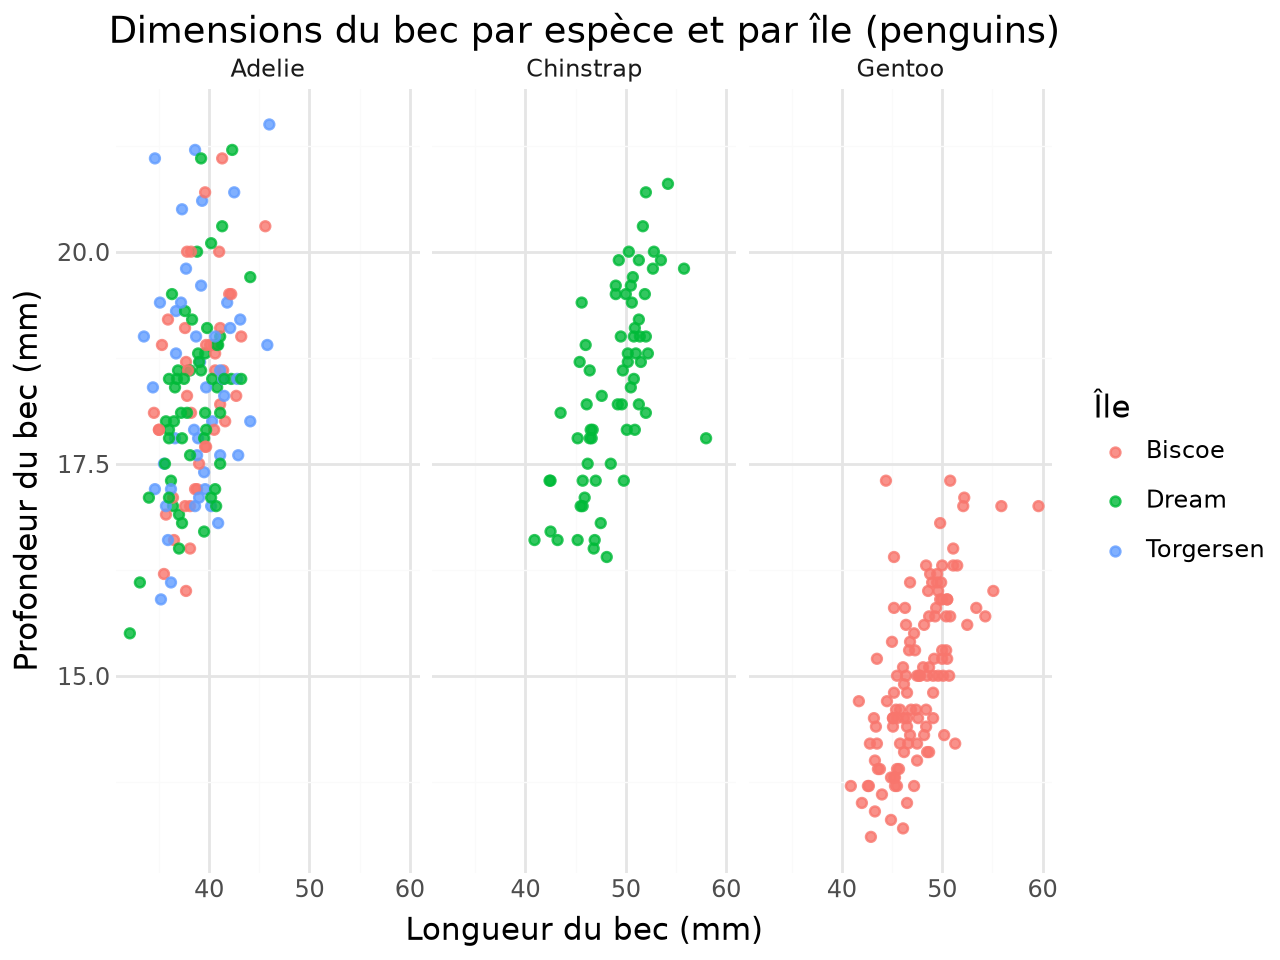

In [9]:
(
    ggplot(penguins, aes(x="bill_length_mm", y="bill_depth_mm", color="island"))
    + geom_point(alpha=0.8)
    + facet_wrap("~ species")
    + labs(
        title="Dimensions du bec par espèce et par île (penguins)",
        x="Longueur du bec (mm)", y="Profondeur du bec (mm)", color="Île",
    )
    + theme_minimal()
)


## 2.2 Ressources Plotnine

- **Dépôt officiel (GitHub)** : [github.com/has2k1/plotnine](https://github.com/has2k1/plotnine)
- **Documentation** : [plotnine.readthedocs.io](https://plotnine.readthedocs.io/en/latest/)
- **Documentation ggplot2 (R)** [ggplot2.tidyverse.org](https://ggplot2.tidyverse.org/) (en complément de la doc de `plotnine`)
- **Cheatsheet officielle ggplot2** pour l’essentiel directement transposable à `plotnine` :
  [rstudio.github.io/cheatsheets/data-visualization.pdf](https://rstudio.github.io/cheatsheets/data-visualization.pdf)

### Mini cheatsheet plotnine

| Composante | Couche |
|---|---|
| Démarrer un graphique | `ggplot(df, aes(x=..., y=...))` |
| Nuage de points | `+ geom_point()` |
| Ligne | `+ geom_line()` |
| Barres (comptage) | `+ geom_bar()` |
| Barres (valeur déjà calculée) | `+ geom_col()` |
| Histogramme | `+ geom_histogram()` |
| Boîte à moustaches | `+ geom_boxplot()` |
| Régression / lissage | `+ geom_smooth(method=...)` |
| Petits multiples | `+ facet_wrap("~ colonne")` ou `facet_grid()` |
| Thème | `+ theme_minimal()`, `theme_bw()`, ... |
| Titres / légendes | `+ labs(title=..., x=..., y=..., color=...)` |
| Sauvegarder | `plot.save("fichier.png", width=..., height=..., dpi=...)` |

Il ne vous reste plus qu’à expérimenter !

# 3. Altair : la grammaire de Vega-Lite en Python

## 3.1 Vega-Lite : une grammaire qui prend en charge l’interactivité

[Altair](https://altair-viz.github.io/) n'est pas une implémentation directe de la grammaire de Wilkinson/Wickham : c'est une **API Python** qui génère des
spécifications [Vega-Lite](https://vega.github.io/vega-lite/). Vega-lite est une grammaire JSON déclarative développée à l'Interactive Data Lab de l'université de
Washington (Satyanarayan, Moritz, Wongsuphasawat & Heer, 2017).

Vega-Lite reprend les mêmes briques conceptuelles que celles vues précédemment (data, encodage, marque, transformation, échelle, facettage) mais ajoute une dimension que `ggplot2` / `plotnine` n'ont pas nativement : une **grammaire de l'interaction**. Dans Vega-Lite, une *selection* (brush, clic, survol...) est un objet de première classe, au même titre qu'un encodage. On peut l'utiliser pour filtrer des données, paramétrer une échelle, ou déclencher une mise en forme conditionnelle.
C'est ce qui permet d'exprimer en quelques lignes des interactions (*brushing & linking*, filtrage croisé) qui demanderaient des dizaines voire des centaines de lignes avec une bibliothèque de bas niveau pour la dataviz comme du `D3.js` pur.

**Vu d’ensemble des différences :**

| | Plotnine / ggplot2 | Altair / Vega-Lite |
|---|---|---|
| Sortie | Image statique (PNG/SVG) | Spécification JSON interactive |
| Construction | Empilement de couches (`+`) | Spécification d'un objet d'encodage (`.encode()`) |
| Interaction | Aucune nativement | Native (`selection`, `.interactive()`) |
| Portabilité | Liée à R/Python + un moteur de rendu image | Le JSON peut être rendu par n'importe quel moteur compatible Vega (navigateur compris) |
| Exécution | Calcul et rendu côté Python | Calcul de spec côté Python, **rendu côté JavaScript** (navigateur) |

L’exécution `.js` est un élément imoportant : un graphique Altair n'est jamais « en Python » au sens strict, c'est une spec JSON exécutée par le moteur Vega
en JavaScript. Altair est donc un **pont direct** entre votre code Python et l'écosystème JS (p. ex. MapLibre pour le géospatial, ou React pour le responsive, etc.).

## 3.2 Exemples (à comparer avec Plotnine)


In [6]:
#!pip install altair # décommentez si vous n’avez pas installé altair

In [12]:
import altair as alt

# Rendu statique (PNG) pour ce notebook : les mêmes graphiques, exécutés en
# Jupyter avec une sortie "live", s'afficheraient nativement en SVG interactif
# sans cette étape. On la conserve ici uniquement pour la lisibilité du
# notebook une fois exporté/partagé.
alt.data_transformers.disable_max_rows()


DataTransformerRegistry.enable('default')

### Exemple A : Nuage de points avec régression (`tips`)

Même encodage que l'exemple `plotnine` : 
- `x` = « addition »
- `y` = « pourboire »
- `color` = « moment du repas ».
- on ajoute une couche de régression avec `transform_regression` pour les droites de tendances, puis on **superpose** les deux couches avec `+` (ici, superposition de couches Altair, pas d'ajout de composants de grammaire comme en `plotnine`).


In [13]:
points = alt.Chart(tips).mark_circle(opacity=0.7).encode(
    x=alt.X("total_bill:Q", title="Addition totale ($)"),
    y=alt.Y("tip:Q", title="Pourboire ($)"),
    color=alt.Color("time:N", title="Moment"),
    tooltip=["total_bill", "tip", "time", "size"],
)

regression = points.transform_regression(
    "total_bill", "tip", groupby=["time"]
).mark_line()

(points + regression).properties(
    title="Pourboire vs addition totale", width=400, height=300
)


alt.LayerChart(...)

### Exemple B : Comparaison par catégories (`iris`)

- une barre par espèce
- hauteur = « longueur moyenne des pétales »

Ici aussi on peut spécifier l'agrégation `mean(petal_length)` directement **dans l'encodage**, on ne calcule toujours pas en amont un `groupby().mean()` pandas en amont (ni non plus une fonction `stat_*` séparée comme en plotnine).

L'agrégation est un simple suffixe sur le champ.


In [14]:
alt.Chart(iris).mark_bar().encode(
    x=alt.X("species:N", title="Espèce"),
    y=alt.Y("mean(petal_length):Q", title="Longueur moyenne du pétale (cm)"),
    color=alt.Color("species:N", legend=None),
).properties(
    title="Longueur moyenne des pétales par espèce (iris)", width=300, height=300
)


alt.Chart(...)

### Exemple C : Distribution par groupe (`tips`)

- une boîte à moustaches par jour (pour comparer la distribution des pourboires)


In [15]:
alt.Chart(tips).mark_boxplot().encode(
    x=alt.X("day:N", title="Jour", sort=["Thur", "Fri", "Sat", "Sun"]),
    y=alt.Y("tip:Q", title="Pourboire ($)"),
    color=alt.Color("day:N", legend=None),
).properties(
    title="Distribution des pourboires par jour", width=300, height=300
)


alt.Chart(...)

### Exemple D : « small-multiples » / facettes (`penguins`)

- un panneau par espèce
- les axes `x`/`y` correspondront aux dimensions du bec (longueur/profondeur)
- `color` = île

Le facettage se fait avec `.facet()`, appliqué à un chart de base, ce qui suit une logique équivalente à `facet_wrap()` en plotnine, implémentant un composant indépendant de l'encodage.


In [16]:
alt.Chart(penguins).mark_circle(opacity=0.8).encode(
    x=alt.X("bill_length_mm:Q", title="Longueur du bec (mm)"),
    y=alt.Y("bill_depth_mm:Q", title="Profondeur du bec (mm)"),
    color=alt.Color("island:N", title="Île"),
).properties(width=180, height=180).facet(
    column=alt.Column("species:N", title=None)
).properties(title="Dimensions du bec par espèce et par île (penguins)")


alt.FacetChart(...)

Il faudrait juste gérer explicitement les valeurs min/max des axes (ici démarrage à 0 par défaut)

### Exemple E : la différence avec Plotnine, l'interactivité en natif

Ici, on va se proposer de relier un nuage de points et un histogramme de comptage. L’interactivité va intervenir dans le sens où on va pouvoir sélectionner une zone (glisser-déposer, *brush*) dans le nuage de points, ce qui va permettre de  **filtrer dynamiquement** l'histogramme. On n’écrira aucune ligne de JavaScript à la main, c'est le compilateur Vega-Lite qui va s’occuper de la gestion des événements et fournir l’output qui va bien.


In [17]:
brush = alt.selection_interval()

scatter = alt.Chart(penguins).mark_circle(opacity=0.7).encode(
    x=alt.X("flipper_length_mm:Q", title="Longueur de nageoire (mm)"),
    y=alt.Y("body_mass_g:Q", title="Masse corporelle (g)"),
    color=alt.condition(brush, "species:N", alt.value("lightgray")),
).add_params(brush).properties(
    width=350, height=300, title="Sélectionnez une zone (glisser-déposer)"
)

bars = alt.Chart(penguins).mark_bar().encode(
    x=alt.X("species:N", title="Espèce"),
    y=alt.Y("count():Q", title="Nombre d'individus sélectionnés"),
    color="species:N",
).transform_filter(brush).properties(
    width=250, height=300, title="Décompte dans la sélection"
)

scatter | bars


alt.HConcatChart(...)

## 3.3 Ressources Altair / Vega-Lite

- **Documentation officielle Altair** : [altair-viz.github.io](https://altair-viz.github.io/)
- **Notebooks tutoriels officiels** : [github.com/altair-viz/altair_notebooks](https://github.com/altair-viz/altair_notebooks)
- **Documentation Vega-Lite** (la grammaire sous-jacente, indépendante du
  binding Python) : [vega.github.io/vega-lite/docs](https://vega.github.io/vega-lite/docs/)
- **Galerie d'exemples Vega-Lite** : [vega.github.io/vega-lite/examples](https://vega.github.io/vega-lite/examples/)
- **Cours complet avec notebooks (Univ. Washington)** :
  [github.com/uwdata/visualization-curriculum](https://github.com/uwdata/visualization-curriculum) ce cours fait référence, car développé par l'équipe à l'origine de Vega-Lite. Il couvre l’encodage, les échelles, les transformations, la composition multi-vues et l’interactivité.

### Mini cheatsheet Altair

| Composante | Implémentation |
|---|---|
| Démarrer un graphique | `alt.Chart(df)` |
| Nuage de points | `.mark_circle()` / `.mark_point()` |
| Ligne | `.mark_line()` |
| Barres | `.mark_bar()` |
| Boîte à moustaches | `.mark_boxplot()` |
| Encoder des canaux | `.encode(x=..., y=..., color=..., tooltip=...)` |
| Agréger dans l'encodage | `"mean(colonne):Q"`, `"count():Q"` |
| Régression | `.transform_regression(...)` |
| Petits multiples | `.facet(column=..., row=...)` |
| Rendre interactif (zoom/pan) | `.interactive()` |
| Sélection (brush, clic) | `alt.selection_interval()` / `alt.selection_point()` |
| Lier une sélection à un encodage | `alt.condition(selection, ..., alt.value(...))` |
| Filtrer selon une sélection | `.transform_filter(selection)` |
| Superposer des couches | `chart_a + chart_b` |
| Juxtaposer horizontalement | `chart_a | chart_b` |
| Sauvegarder | `chart.save("fichier.png")` ou `.save("fichier.html")` |


---
# 4. Conclusion : comment et quand utiliser une grammaire de visualisation

## Point commun entre les deux bibliothèques

Qu'on écrive `+ geom_point()` ou `.mark_circle().encode(...)`, le raisonnement de fond est identique : on ne choisit pas un « type de graphique » dans un catalogue, on **mappe des colonnes de données sur des canaux visuels** (position, couleur, taille, forme), et on laisse la grammaire gérer les détails (échelles, légendes, axes). Ça ne signifie pas qu’on ne choisit pas quel type de graphe utiliser, c’est juste qu’on ne part pas du type de graphe pour adapter les indications qu’on donne sur les composante à la manière dont le langage ou le module qu’on utilise implémente l’affichage du graphe. On adopte une discipline de pensée où on définit chaque élément indépendamment, la syntaxe devient secondaire car très régulière (elle ne change pas en fonction du type de graphe qu’on veut écrire). Cette approche ou manière de penser reste valable que l’on utilise `ggplot2` en R, Vega-Lite directement en JS, ou toute autre implémentation de la même idée.

## Quand préférer Plotnine

- Vous (ou votre équipe) connaissez déjà ggplot2/R, et voulez transférer cette syntaxe telle quelle en Python
- Le livrable final est une **image statique** : rapport, article, illustration scientifique destinée à publication
- Vous avez besoin d'un contrôle fin sur l'esthétique statique en étant attentif à la robustesse et la maturité de la solution (ggplot2 a 15+ ans de maturité sur les thèmes, les échelles, les annotations)
- Pas de besoin d'interactivité ni de déploiement web

## Quand préférer Altair

- Le livrable est destiné à être **consulté dans un navigateur** : notebook partagé, dashboard, page web, etc.
- Vous avez besoin d'une interactivité même légère (zoom, tooltip, sélection croisée) sans écrire de JavaScript
- Vous voulez que la spécification du graphique (le JSON) soit **portable**, c’est-à-dire réutilisable côté JS, intégrable dans une page web sans réécrire le graphique
- Le projet pourrait évoluer vers un vrai outil interactif (lien naturel vers Vega-Lite pur, voire en rajoutant du `D3` si le besoin dépasse ce que Vega-Lite permet)

## Pour le projet du module

Vu la nature des livrables demandés (UX/UI, interactivité, accessibilité), **Altair est probablement le choix par défaut le plus pertinent** pour l'app de
visualisation que vous allez construire : il reste du Python, mais produit nativement des objets interactifs et s'intègre bien dans Streamlit/Dash (tous
deux savent afficher un chart Altair, attention c’est quand même beaucoup plus compliqué avec Dash). Plotnine reste un bon choix si une partie du livrable est destinée à un rapport statique (figures pour un document, une présentation imprimée).

Dans les deux cas, l'essentiel reste ce qu’on a vu en introduction : avant d'écrire la moindre ligne de code, demandez-vous *quel encodage sert la tâche analytique visée*, et seulement ensuite choisir l'outil qui permet de l’implémenter le plus directement.
